In [18]:
from pathlib import Path
import os
import numpy as np
import matplotlib.pyplot as plt

In [19]:
os.environ["PATH"] = "/vast/palmer/apps/avx2/software/texlive/20220321-GCC-12.2.0/bin/x86_64-linux:" + os.environ["PATH"]
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
    "text.latex.preamble": r"\usepackage{amsmath} \usepackage{lmodern}",
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "axes.linewidth": 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6,
    "figure.figsize": [8, 5.6],
    "svg.fonttype": "none",
})

In [20]:
MIX_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/mix")
SAMPLE_DATA_DIR = Path("/home/rg2248/project/friction/data/local-friction/uniform/sample")

# Must match mixing/ga-mix.py
N_ORIENTATIONS = 5009
N_POINTS = 5003

In [21]:
def load_mix_data(data_dir):
    records = []

    for path in sorted(data_dir.glob("mu-*-mu-*.npz")):
        record = dict(np.load(path))
        record["path"] = path
        records.append(record)

    return records


def sample_ss_mean(sample_dir, mu_eff):
    return float(np.load(sample_dir / f"mu-{mu_eff}.npz")["ss"].mean())


def predicted_mix_rules(sample_dir, mu_low, mu_high):
    mu_i = sample_ss_mean(sample_dir, mu_low)
    mu_j = sample_ss_mean(sample_dir, mu_high)

    return {
        "arithmetic": 0.5 * (mu_i + mu_j),
        "geometric": float(np.sqrt(mu_i * mu_j)),
        "harmonic": 2 * mu_i * mu_j / (mu_i + mu_j),
        "min": min(mu_i, mu_j),
    }


def mix_mean_and_sem(record):
    mix_lh = np.asarray(record["mix_lh"]).reshape(N_ORIENTATIONS, N_POINTS)
    mix_hl = np.asarray(record["mix_hl"]).reshape(N_ORIENTATIONS, N_POINTS)
    combined = np.concatenate([mix_lh, mix_hl], axis=0)

    orientation_means = combined.mean(axis=1)
    mean = float(combined.mean())
    sem = float(orientation_means.std(ddof=1) / np.sqrt(combined.shape[0]))

    return mean, sem

In [22]:
records = load_mix_data(MIX_DATA_DIR)

asperity_diameter_low = np.array([
    2 * float(record["asperity_radius_low"])
    for record in records
])
mu_local_mean = np.zeros(len(records))
predicted = {
    key: np.zeros(len(records))
    for key in ("arithmetic", "geometric", "harmonic", "min")
}

for i, record in enumerate(records):
    print(f"Processing {record['path']}")
    mu_local_mean[i], _ = mix_mean_and_sem(record)
    rules = predicted_mix_rules(
        SAMPLE_DATA_DIR,
        float(record["mu_low"]),
        float(record["mu_high"]),
    )
    for key in predicted:
        predicted[key][i] = rules[key]

order = np.argsort(asperity_diameter_low)
asperity_diameter_low = asperity_diameter_low[order]
mu_local_mean = mu_local_mean[order]
for key in predicted:
    predicted[key] = predicted[key][order]

Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-0.01-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-0.03-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-0.05-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-0.1-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-0.3-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-0.5-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-1.0-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-3.0-mu-10.0.npz
Processing /home/rg2248/project/friction/data/local-friction/uniform/mix/mu-5.0-mu-10.0.npz


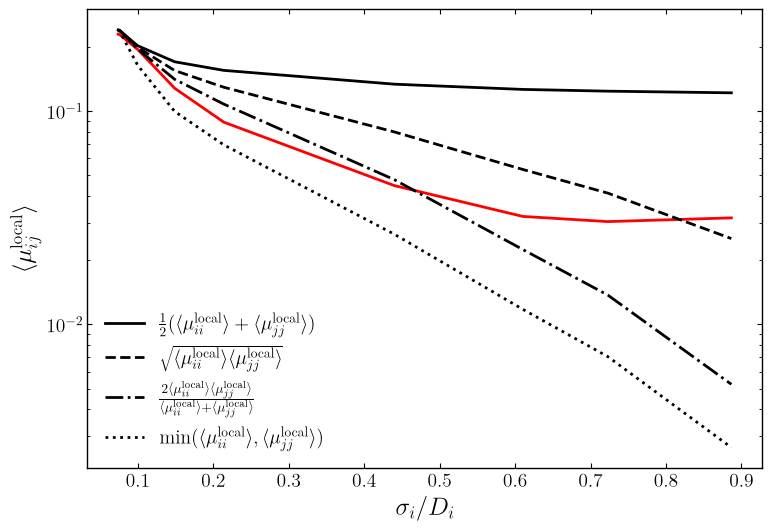

In [25]:
fig, ax = plt.subplots()

ax.plot(
    asperity_diameter_low,
    mu_local_mean,
    color="red",
    linestyle="-",
    label="_nolegend_",
)

prediction_styles = {
    "arithmetic": ("solid", r"$\tfrac{1}{2}(\langle\mu^{\mathrm{local}}_{ii}\rangle + \langle\mu^{\mathrm{local}}_{jj}\rangle)$"),
    "geometric": ("dashed", r"$\sqrt{\langle\mu^{\mathrm{local}}_{ii}\rangle\langle\mu^{\mathrm{local}}_{jj}\rangle}$"),
    "harmonic": ("dashdot", r"$\tfrac{2\langle\mu^{\mathrm{local}}_{ii}\rangle\langle\mu^{\mathrm{local}}_{jj}\rangle}{\langle\mu^{\mathrm{local}}_{ii}\rangle + \langle\mu^{\mathrm{local}}_{jj}\rangle}$"),
    "min": ("dotted", r"$\min(\langle\mu^{\mathrm{local}}_{ii}\rangle, \langle\mu^{\mathrm{local}}_{jj}\rangle)$"),
}

for key, (linestyle, label) in prediction_styles.items():
    ax.plot(
        asperity_diameter_low,
        predicted[key],
        color="black",
        linestyle=linestyle,
        label=label,
    )

ax.set_yscale("log")
ax.set_xlabel(r"$\sigma_i/D_i$")
ax.set_ylabel(r"$\langle\mu^{\mathrm{local}}_{ij}\rangle$")
ax.legend(frameon=False)
plt.tight_layout()

figure_path = Path("../figures/mixing/mixing-rules.png")
figure_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(figure_path, dpi=600, bbox_inches="tight")
plt.show()